In [ ]:
import anndata as ad
import torch
import pytorch_lightning as pl
from scdiff.dataset import ScDataModule
from scdiff.ae import LightningAE
import scanpy as sc
import os
from scdiff.utils import compare_umap

In [ ]:
adata = ad.read_h5ad('data/Alles_filtered.h5ad')
adata.var_names_make_unique()
display(adata.X)
display(adata.obs)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adatamodule = ScDataModule(adata, "cell_type1", "LabelEncoder")
ae_model = LightningAE(n_genes=adata.X.shape[1])

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/ae"
)

ae_model_path = "checkpoints/trained_ae_model.ckpt"
if os.path.exists(ae_model_path):
    # read the model from the checkpoint
    ae_model = LightningAE.load_from_checkpoint("checkpoints/trained_ae_model.ckpt")
else:
    trainer.fit(ae_model, adatamodule)
    trainer.save_checkpoint(ae_model_path)
    
X_dense = adata.X.toarray()

# Convert to torch tensor and move to same device as model
device = next(ae_model.parameters()).device
X_tensor = torch.tensor(X_dense, dtype=torch.float32).to(device)

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/tqdm/auto.py:21: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 5236395 stored elements and shape (4614, 11835)>

,cell_type1,data_type,cell_ontology_class,n_genes,n_counts
cell_id,,,,,
ACTTAGCGTTTN,undifferentiated cells,raw,nan,1588,5416
ATACACCCGCCC,undifferentiated cells,raw,nan,1165,4032
TCGGCGATGTAT,undifferentiated cells,raw,nan,1134,3992
GTTCGCCGTCGA,undifferentiated cells,raw,nan,1706,8109
CTAATCGCTAGT,undifferentiated cells,raw,nan,810,2743
...,...,...,...,...,...
TTTTAAGACGGN,LVM longitudinal visc. muscle,raw,visceral muscle cell,1027,3737
TCTTCACGAAGA,LVM longitudinal visc. muscle,raw,visceral muscle cell,1548,5824
GTTGCAATGGAG,LVM longitudinal visc. muscle,raw,visceral muscle cell,1136,3099


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [2]:
from src.lightning_diffusion import LightningDiffusion
ae_model.eval()
with torch.no_grad():
    latent = ae_model.encode(X_tensor).cpu().numpy()  # shape [n_cells, latent_dim]

# standardize the latent space
latent = (latent - latent.mean(axis=0)) / latent.std(axis=0)
latent_adata = ad.AnnData(latent, obs=adata.obs.copy())

latent_dm = ScDataModule(latent_adata, label_key="cell_type1",
                        encoder="LabelEncoder", batch_size=128, val_split=0.1)
latent_dm.setup()

dim = latent.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999,
)

trainer = pl.Trainer(
    max_epochs=200,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/diffusion"
)

diffusion_model_path = "checkpoints/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | DenoisingUNet     | 7.2 M  | train
1 | diffusion | GaussianDiffusion | 7.2 M  | train
2 | ema_model | DenoisingUNet     | 7.2 M  | eval 
--------------------------------------------------------
7.2 M     Trainable params
7.2 M     Non-trainable params
14.3 M    Total params
57.386    Total estimated model params size (MB)
92        Modules in train mode
91        Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (33) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:527: Found 91 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 199: 100%|██████████| 33/33 [00:01<00:00, 23.60it/s, v_num=4, val_loss=0.309, train_loss=0.297]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 33/33 [00:01<00:00, 20.40it/s, v_num=4, val_loss=0.309, train_loss=0.297]


DDIM sampling: 100%|██████████| 50/50 [00:30<00:00,  1.63it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[43.877304, 41.982265],
        [40.8301  , 41.17474 ],
        [42.058533, 40.344883],
        ...,
        [41.338215, 41.49579 ],
        [43.980843, 36.068844],
        [43.23045 , 39.540623]], shape=(4614, 2), dtype=float32),
 array([[43.02253 , 39.085037],
        [40.04264 , 43.408676],
        [48.187447, 42.61012 ],
        ...,
        [44.042908, 36.02005 ],
        [48.727997, 42.35877 ],
        [48.51685 , 42.397682]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

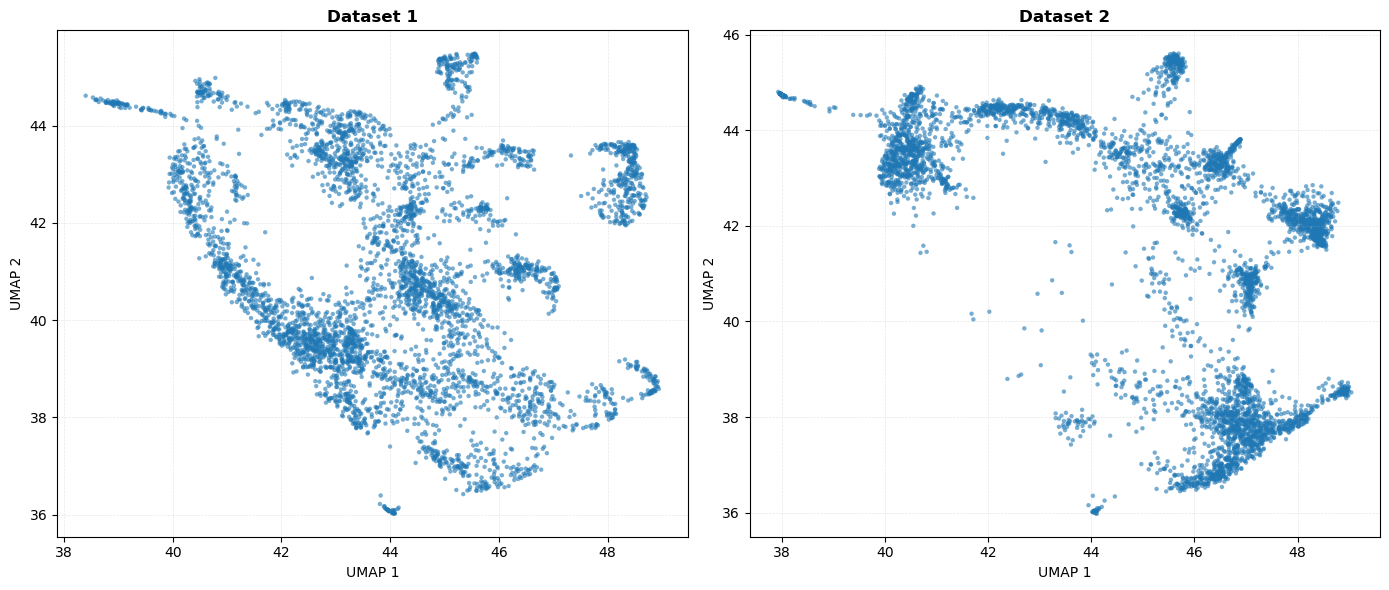

In [5]:
real_labels = latent_dm.train_dataset.dataset.classes
device = next(diffusion.parameters()).device
labels_tensor = torch.tensor(real_labels, dtype=torch.long).to(device)


latent_samples = diffusion.sample(num_samples=len(latent_adata),
                                      sampling_timesteps=50,
                                    labels=labels_tensor,
                                    ddim_sampling_eta=0.1,
                                    use_ema=True,
                                    clip_denoised=False)
compare_umap(latent_adata.X, latent_samples)

In [13]:
samples_dir = "data/latnet_samples"
os.makedirs(samples_dir, exist_ok=True)
torch.save(latent_samples, f"{samples_dir}/ddim50_samples.pt")

DDIM sampling: 100%|██████████| 50/50 [00:14<00:00,  3.41it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[ 0.9682334, 81.87829  ],
        [ 1.978833 , 79.58467  ],
        [ 0.8014212, 79.76449  ],
        ...,
        [ 1.348533 , 80.30432  ],
        [-0.8785725, 81.72961  ],
        [-0.7712438, 79.957726 ]], shape=(4614, 2), dtype=float32),
 array([[ 2.525422 , 84.518654 ],
        [ 4.106213 , 82.23006  ],
        [ 1.1942633, 84.47752  ],
        ...,
        [ 1.3159018, 81.64524  ],
        [-5.236291 , 81.00188  ],
        [-4.594763 , 81.990105 ]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

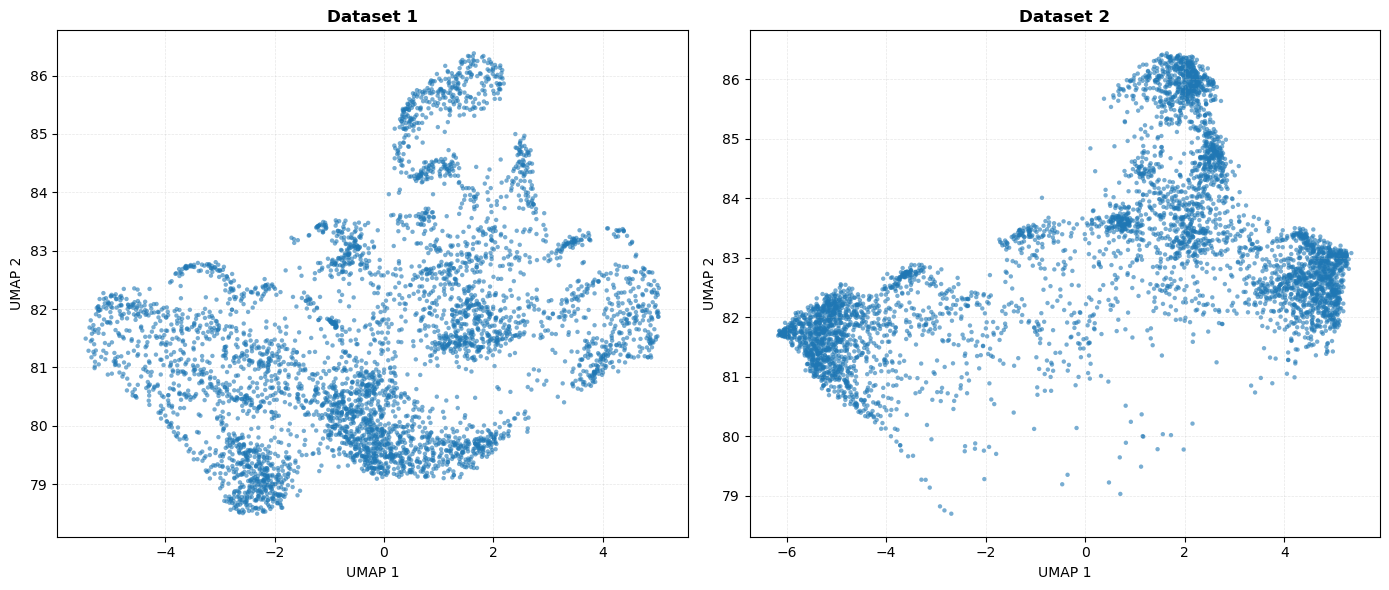

In [6]:
latent_samples_null = diffusion.sample(num_samples=len(latent_adata),
                                      sampling_timesteps=50,
                                    labels=None,
                                    ddim_sampling_eta=0.1,
                                    use_ema=False,
                                    clip_denoised=False)
compare_umap(latent_adata.X, latent_samples_null)

In [ ]:
samples_dir = "data/Alles_latnet_samples"
os.makedirs(samples_dir, exist_ok=True)
torch.save(latent_samples, f"{samples_dir}/ddim50_samples_null.pt")

DDIM sampling: 100%|██████████| 50/50 [00:13<00:00,  3.59it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[-13.57078 ,  77.01267 ],
        [-12.314655,  75.63289 ],
        [-13.857516,  75.43425 ],
        ...,
        [-12.13972 ,  76.29092 ],
        [-16.062159,  77.20327 ],
        [-15.846344,  75.51535 ]], shape=(4614, 2), dtype=float32),
 array([[-20.671057 ,  76.08146  ],
        [-13.622162 ,  81.1824   ],
        [-19.631048 ,  76.2329   ],
        ...,
        [-12.9191065,  80.302635 ],
        [-15.405763 ,  78.443794 ],
        [-14.121791 ,  78.99931  ]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

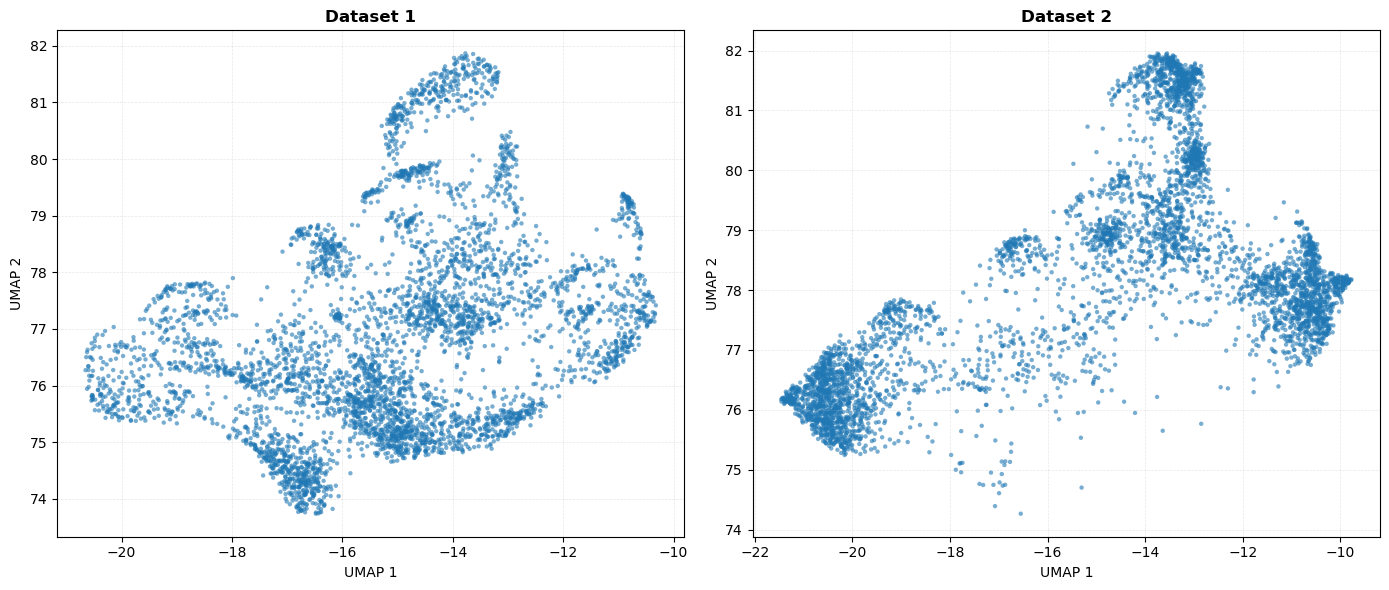

In [7]:
latent_samples_null = diffusion.sample(num_samples=len(latent_adata),
                                      sampling_timesteps=50,
                                    labels=None,
                                    ddim_sampling_eta=0.1,
                                    use_ema=True,
                                    clip_denoised=False)
compare_umap(latent_adata.X, latent_samples_null)

  Class 0: 47 (1.0%)
  Class 1: 199 (4.3%)
  Class 2: 650 (14.1%)
  Class 3: 221 (4.8%)
  Class 4: 82 (1.8%)
  Class 5: 82 (1.8%)
  Class 6: 339 (7.3%)
  Class 7: 107 (2.3%)
  Class 8: 308 (6.7%)
  Class 9: 545 (11.8%)
  Class 10: 155 (3.4%)
  Class 11: 1512 (32.8%)
  Class 12: 248 (5.4%)
  Class 13: 119 (2.6%)


DDIM sampling: 100%|██████████| 50/50 [00:26<00:00,  1.90it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


  Class 0: 47 (1.0%)
  Class 1: 199 (4.3%)
  Class 2: 650 (14.1%)
  Class 3: 221 (4.8%)
  Class 4: 82 (1.8%)
  Class 5: 82 (1.8%)
  Class 6: 339 (7.3%)
  Class 7: 107 (2.3%)
  Class 8: 308 (6.7%)
  Class 9: 545 (11.8%)
  Class 10: 155 (3.4%)
  Class 11: 1512 (32.8%)
  Class 12: 248 (5.4%)
  Class 13: 119 (2.6%)
Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


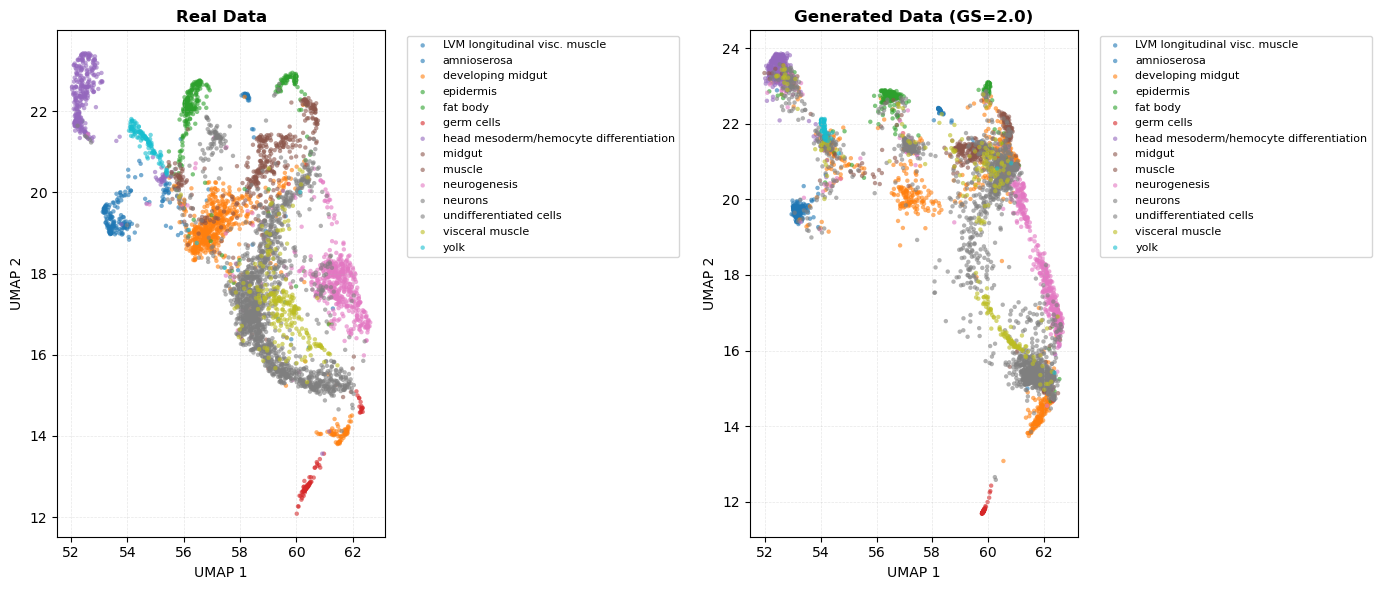

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(latent_adata.obs['cell_type1'])
full_labels = le.transform(latent_adata.obs['cell_type1'])

device = next(diffusion.parameters()).device
labels_tensor = torch.tensor(full_labels, dtype=torch.long).to(device)

diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(
        num_samples=len(full_labels),
        sampling_timesteps=50,
        labels=labels_tensor,
        ddim_sampling_eta=0.1,
        use_ema=True,
        clip_denoised=False
    )

emb1, emb2, fig = compare_umap(
    latent_adata.X, 
    latent_samples.cpu().numpy(),
    labels1=le.inverse_transform(full_labels),  
    labels2=le.inverse_transform(full_labels),
    title1="Real Data",
    title2="Generated Data (GS=2.0)",
    random_state=42
)


  Class 0: 47 (1.0%)
  Class 1: 199 (4.3%)
  Class 2: 650 (14.1%)
  Class 3: 221 (4.8%)
  Class 4: 82 (1.8%)
  Class 5: 82 (1.8%)
  Class 6: 339 (7.3%)
  Class 7: 107 (2.3%)
  Class 8: 308 (6.7%)
  Class 9: 545 (11.8%)
  Class 10: 155 (3.4%)
  Class 11: 1512 (32.8%)
  Class 12: 248 (5.4%)
  Class 13: 119 (2.6%)
ddpm sampling...


sampling loop time step: 100%|██████████| 1000/1000 [13:37<00:00,  1.22it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


  Class 0: 47 (1.0%)
  Class 1: 199 (4.3%)
  Class 2: 650 (14.1%)
  Class 3: 221 (4.8%)
  Class 4: 82 (1.8%)
  Class 5: 82 (1.8%)
  Class 6: 339 (7.3%)
  Class 7: 107 (2.3%)
  Class 8: 308 (6.7%)
  Class 9: 545 (11.8%)
  Class 10: 155 (3.4%)
  Class 11: 1512 (32.8%)
  Class 12: 248 (5.4%)
  Class 13: 119 (2.6%)
Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


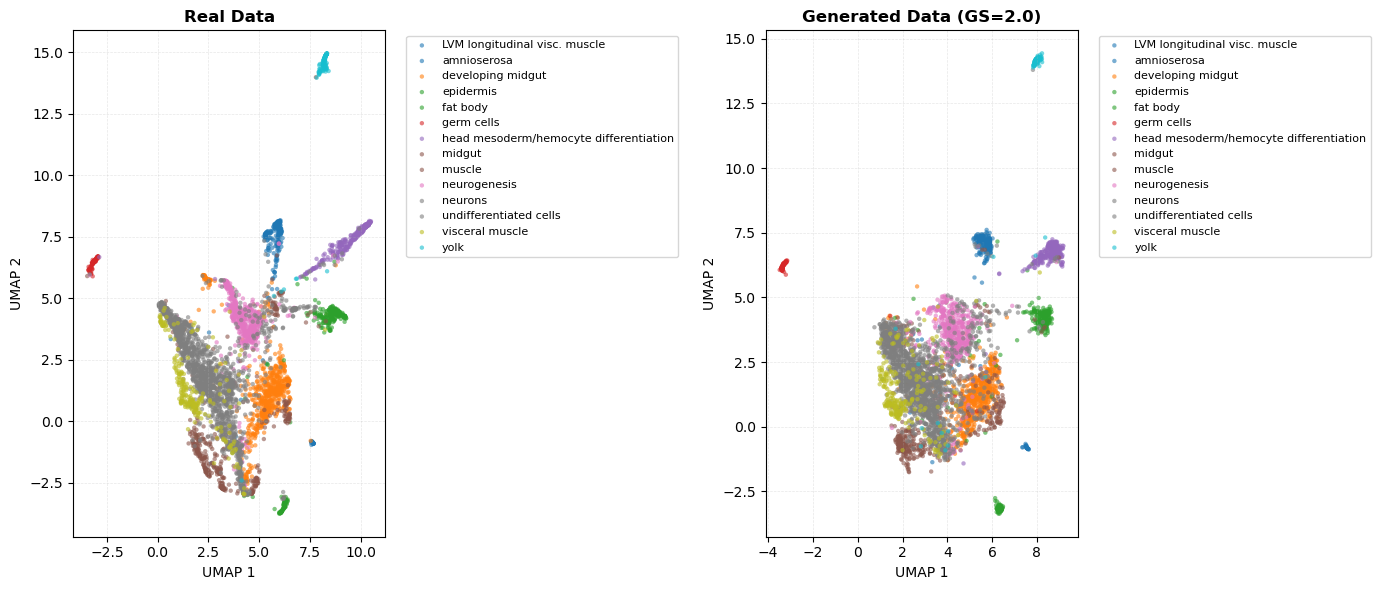

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(latent_adata.obs['cell_type1'])
full_labels = le.transform(latent_adata.obs['cell_type1'])

device = next(diffusion.parameters()).device
labels_tensor = torch.tensor(full_labels, dtype=torch.long).to(device)

print("ddpm sampling...")
diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(
        num_samples=len(full_labels),
        sampling_timesteps=None,
        labels=labels_tensor,
        ddim_sampling_eta=0.1,
        use_ema=True,
        clip_denoised=False
    )


emb1, emb2, fig = compare_umap(
    latent_adata.X, 
    latent_samples.cpu().numpy(),
    labels1=le.inverse_transform(full_labels),  
    labels2=le.inverse_transform(full_labels),
    title1="Real Data",
    title2="Generated Data (GS=2.0)",
    random_state=42
)


DDIM sampling: 100%|██████████| 900/900 [10:52<00:00,  1.38it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


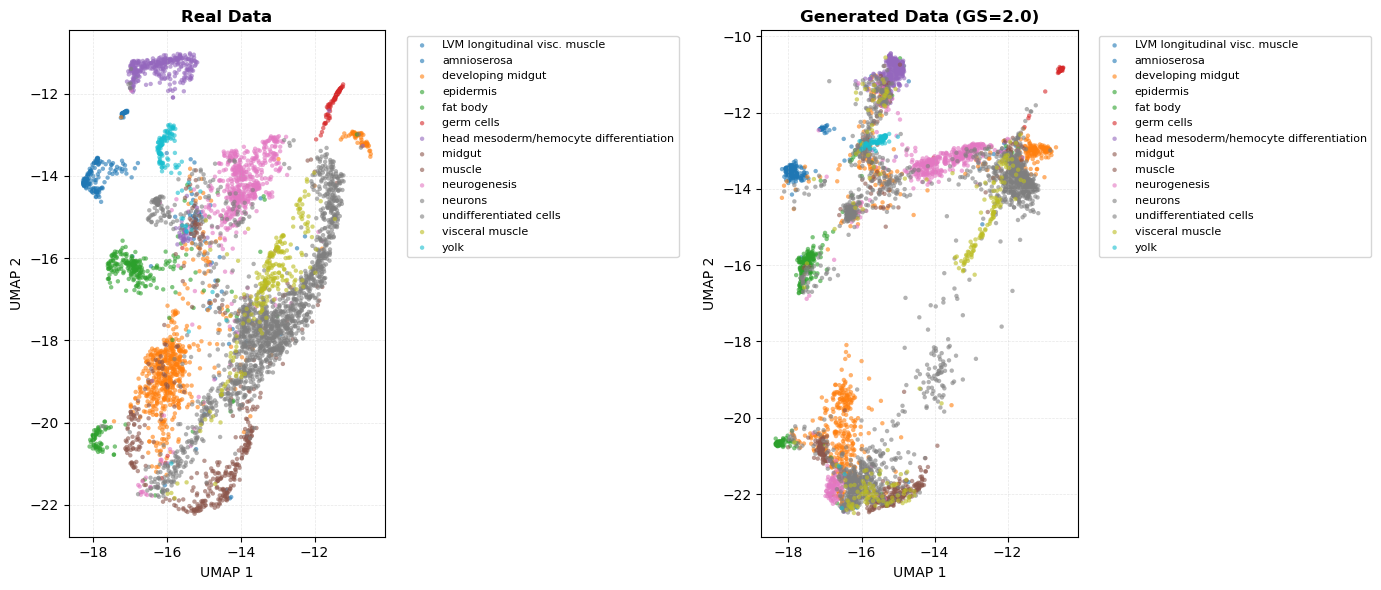

In [10]:
le = LabelEncoder()
le.fit(latent_adata.obs['cell_type1'])
full_labels = le.transform(latent_adata.obs['cell_type1'])

device = next(diffusion.parameters()).device
labels_tensor = torch.tensor(full_labels, dtype=torch.long).to(device)

diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(
        num_samples=len(full_labels),
        sampling_timesteps=900,
        labels=labels_tensor,
        ddim_sampling_eta=0.1,
        use_ema=True,
        clip_denoised=False
    )

emb1, emb2, fig = compare_umap(
    latent_adata.X, 
    latent_samples.cpu().numpy(),
    labels1=le.inverse_transform(full_labels),  
    labels2=le.inverse_transform(full_labels),
    title1="Real Data",
    title2="Generated Data (GS=2.0)",
    random_state=42
)


In [15]:
torch.save(latent_samples, f"{samples_dir}/ddim900_samples.pt")

sampling loop time step: 100%|██████████| 1000/1000 [12:35<00:00,  1.32it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[ 1.9256877 ,  5.343891  ],
        [ 0.25738636,  3.9379647 ],
        [ 1.8952487 ,  4.0156403 ],
        ...,
        [ 0.21440277,  3.3620021 ],
        [-1.0370153 ,  7.457709  ],
        [ 4.3338    ,  2.7459025 ]], shape=(4614, 2), dtype=float32),
 array([[3.4863074, 2.0707226],
        [1.3241271, 3.9967518],
        [2.703245 , 4.278351 ],
        ...,
        [1.6181394, 3.2946725],
        [5.4748254, 4.999561 ],
        [2.715798 , 3.3895726]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

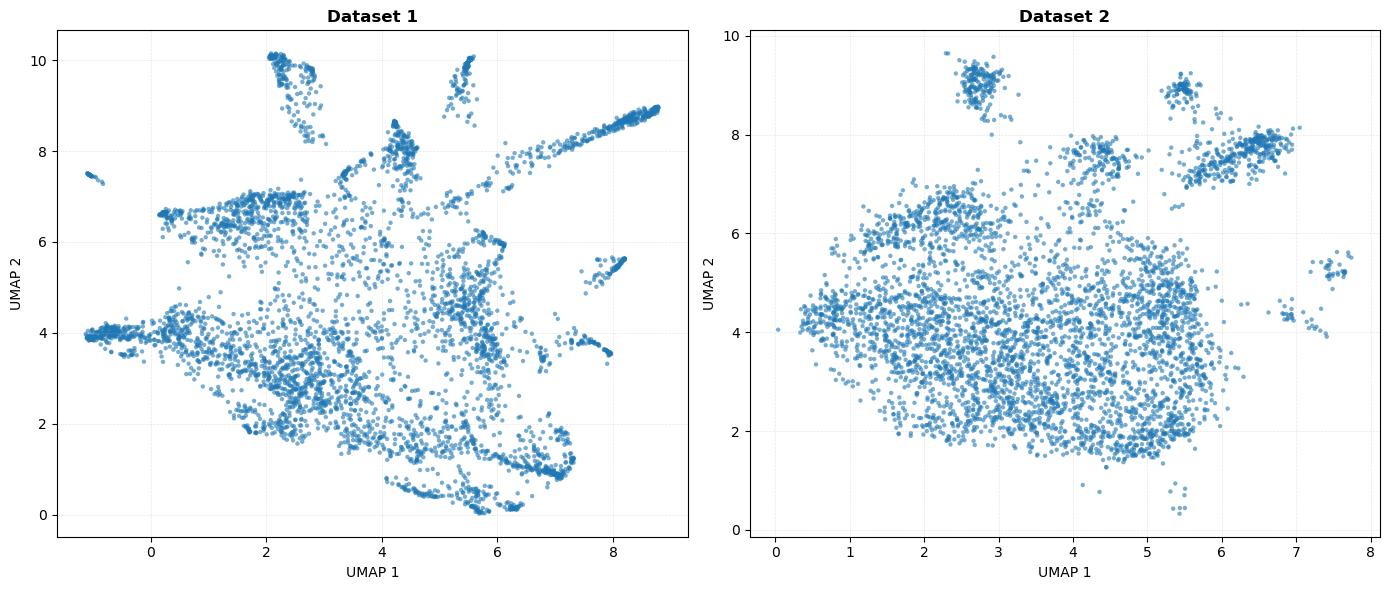

In [10]:
ddpm_latent_samples = diffusion.sample(num_samples=len(latent_adata),
                                    labels=labels_tensor,
                                    sampling_timesteps=None)
compare_umap(latent_adata.X, ddpm_latent_samples)